# Data exploration — Prédiction du prix immobilier
## Notebook 01 : Analyse Exploratoire des Données

### Objectifs de ce Notebook

**ÉTAPE 1 : Séparation des Données Brutes et Exploration**
- 1.1 — Chargement du dataset brut et séparation train/test
- 1.2 — Aperçu des Données d'Entraînement
- 1.3 — Vérification des Doublons
- 1.4 — Valeurs Manquantes
- 1.5 — Types de Données & Complétude
- 1.6 — Statistiques Descriptives des Variables Numériques
- 1.7 — Échantillonnage Aléatoire
- 1.8 — Stratégies de Traitement des Valeurs Manquantes
- 1.9 — Analyse Univariée des Variables Catégorielles
- 1.10 — Détection des Outliers (Méthode IQR)
- 1.11 — Matrice de Corrélation (Variables Numériques)
- 1.12 — Analyse Bivariée : Prix de Vente par Variable Catégorielle
- 1.13 — Test Statistique : Significativité des Variables Catégorielles (ANOVA / Kruskal-Wallis)

**ÉTAPE 2 : Analyse de la Variable Cible (SALE PRICE)**
- Distribution des prix de vente, diagnostic de normalité et implications pour la modélisation

**Synthèse de l'Exploration**
- Qualité des données, insights clés et prochaines étapes (Notebook 02)

In [1]:
"""
Configuration de l'environnement — Prediction du prix immobilier
===================================================
Imports et configuration pour l'analyse exploratoire des données immobilières.
"""

import os
import sys

# Manipulation des données
import pandas as pd
import numpy as np

# Statistiques et tests
import scipy.stats as ss

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Séparation des données
from sklearn.model_selection import train_test_split

# Seed pour la reproductibilité
RANDOM_STATE = 1204

# Import de la fonction utilitaire depuis utils/data_prep.py
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.data_prep import detect_possible_outliers

print(" Imports chargés avec succès")

 Imports chargés avec succès


In [2]:
# Vérification du répertoire de travail
print(f" Répertoire courant : {os.getcwd()}")

 Répertoire courant : c:\Users\juber\Documents\Scoring & prédiction de prix immobilier (Régression)\notebooks


---

# ÉTAPE 1 : Séparation des Données Brutes et Exploration

## Objectif
Charger les données immobilières, les séparer en jeu d'entraînement et de test, puis explorer leur structure, qualité et composition.

### 1.1 — Chargement du dataset brut et séparation train/test

### Questions à Répondre
- Quel est le volume du dataset ? (lignes / colonnes)
- Comment sont structurées les données ?
- Les types de colonnes sont-ils cohérents ?
- Y a-t-il des problèmes évidents ?

In [3]:
# ============================================================
# Chargement du dataset brut
# ============================================================
df = pd.read_csv("..\\data\\nyc-rolling-sales.csv")
print(f" Dataset importé : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")

 Dataset importé : 84548 lignes et 22 colonnes



In [4]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

In [5]:
#Affichage des premières lignes du dataset
df.head()


,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [6]:
#Affichage d'une ligne aléatoire du dataset
df.sample()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
42274,16923,3,MIDWOOD,01 ONE FAMILY DWELLINGS,1,7627,58,,A9,1130 EAST 28TH STREET,...,1,0,1,2000,1296,1925,1,A9,770000,2017-02-28 00:00:00


In [7]:
# ============================================================
# Séparation features / cible
# ============================================================
Target = "SALE PRICE"

# Conversion de la cible en numérique (valeurs comme " - " → NaN)
df[Target] = pd.to_numeric(df[Target], errors="coerce")

X = df.drop(columns=[Target])
y = df[Target]

# --- Train / Test Split (80/20) — Régression, pas de stratify ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# --- Affichage des dimensions ---
print("\n" + "=" * 70)
print("  DIMENSIONS DES DONNÉES")
print("=" * 70)
print(f"  Variables explicatives (X_train) : {X_train.shape}")
print(f"  Variable cible         (y_train) : {y_train.shape}")
print("-" * 70)
print(f"  Variables explicatives (X_test)  : {X_test.shape}")
print(f"  Variable cible         (y_test)  : {y_test.shape}")
print("=" * 70)


  DIMENSIONS DES DONNÉES
  Variables explicatives (X_train) : (67638, 21)
  Variable cible         (y_train) : (67638,)
----------------------------------------------------------------------
  Variables explicatives (X_test)  : (16910, 21)
  Variable cible         (y_test)  : (16910,)


In [8]:
# Identification des types de variables sur le jeu d'entraînement
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f" {len(cat_cols)} variables catégorielles : {cat_cols}\n")
print(f" {len(num_cols)} variables numériques    : {num_cols}\n")
print(f" Total : {len(cat_cols) + len(num_cols)} variables")

 11 variables catégorielles : ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'EASE-MENT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILDING CLASS AT TIME OF SALE', 'SALE DATE']

 10 variables numériques    : ['Unnamed: 0', 'BOROUGH', 'BLOCK', 'LOT', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE']

 Total : 21 variables


In [9]:
# --- 1.2 — Aperçu des Données d'Entraînement ---
# Statistiques descriptives rapides de la variable cible
print(" APERÇU DE LA VARIABLE CIBLE — SALE PRICE (y_train)")
print("=" * 70)
print(f"  Nombre de transactions  : {y_train.shape[0]}")
print(f"  Valeurs manquantes      : {y_train.isna().sum()} ({y_train.isna().mean()*100:.2f}%)")
print(f"  Prix moyen              : ${y_train.mean():,.2f}")
print(f"  Prix médian             : ${y_train.median():,.2f}")
print(f"  Écart-type              : ${y_train.std():,.2f}")
print(f"  Min                     : ${y_train.min():,.2f}")
print(f"  Max                     : ${y_train.max():,.2f}")
print("=" * 70)

 APERÇU DE LA VARIABLE CIBLE — SALE PRICE (y_train)
  Nombre de transactions  : 67638
  Valeurs manquantes      : 11745 (17.36%)
  Prix moyen              : $1,273,558.56
  Prix médian             : $530,000.00
  Écart-type              : $11,414,652.30
  Min                     : $0.00
  Max                     : $2,210,000,000.00


In [10]:
# Histogramme de la distribution de SALE PRICE (y_train)
fig = px.histogram(
    y_train.dropna(),
    nbins=100,
    title="Distribution de SALE PRICE (y_train)",
    labels={"value": "Prix de vente ($)", "count": "Nombre de transactions"},
)

fig.update_layout(
    xaxis_title="Prix de vente ($)",
    yaxis_title="Nombre de transactions",
    showlegend=False,
    width=800,
    height=400
)

fig.show()

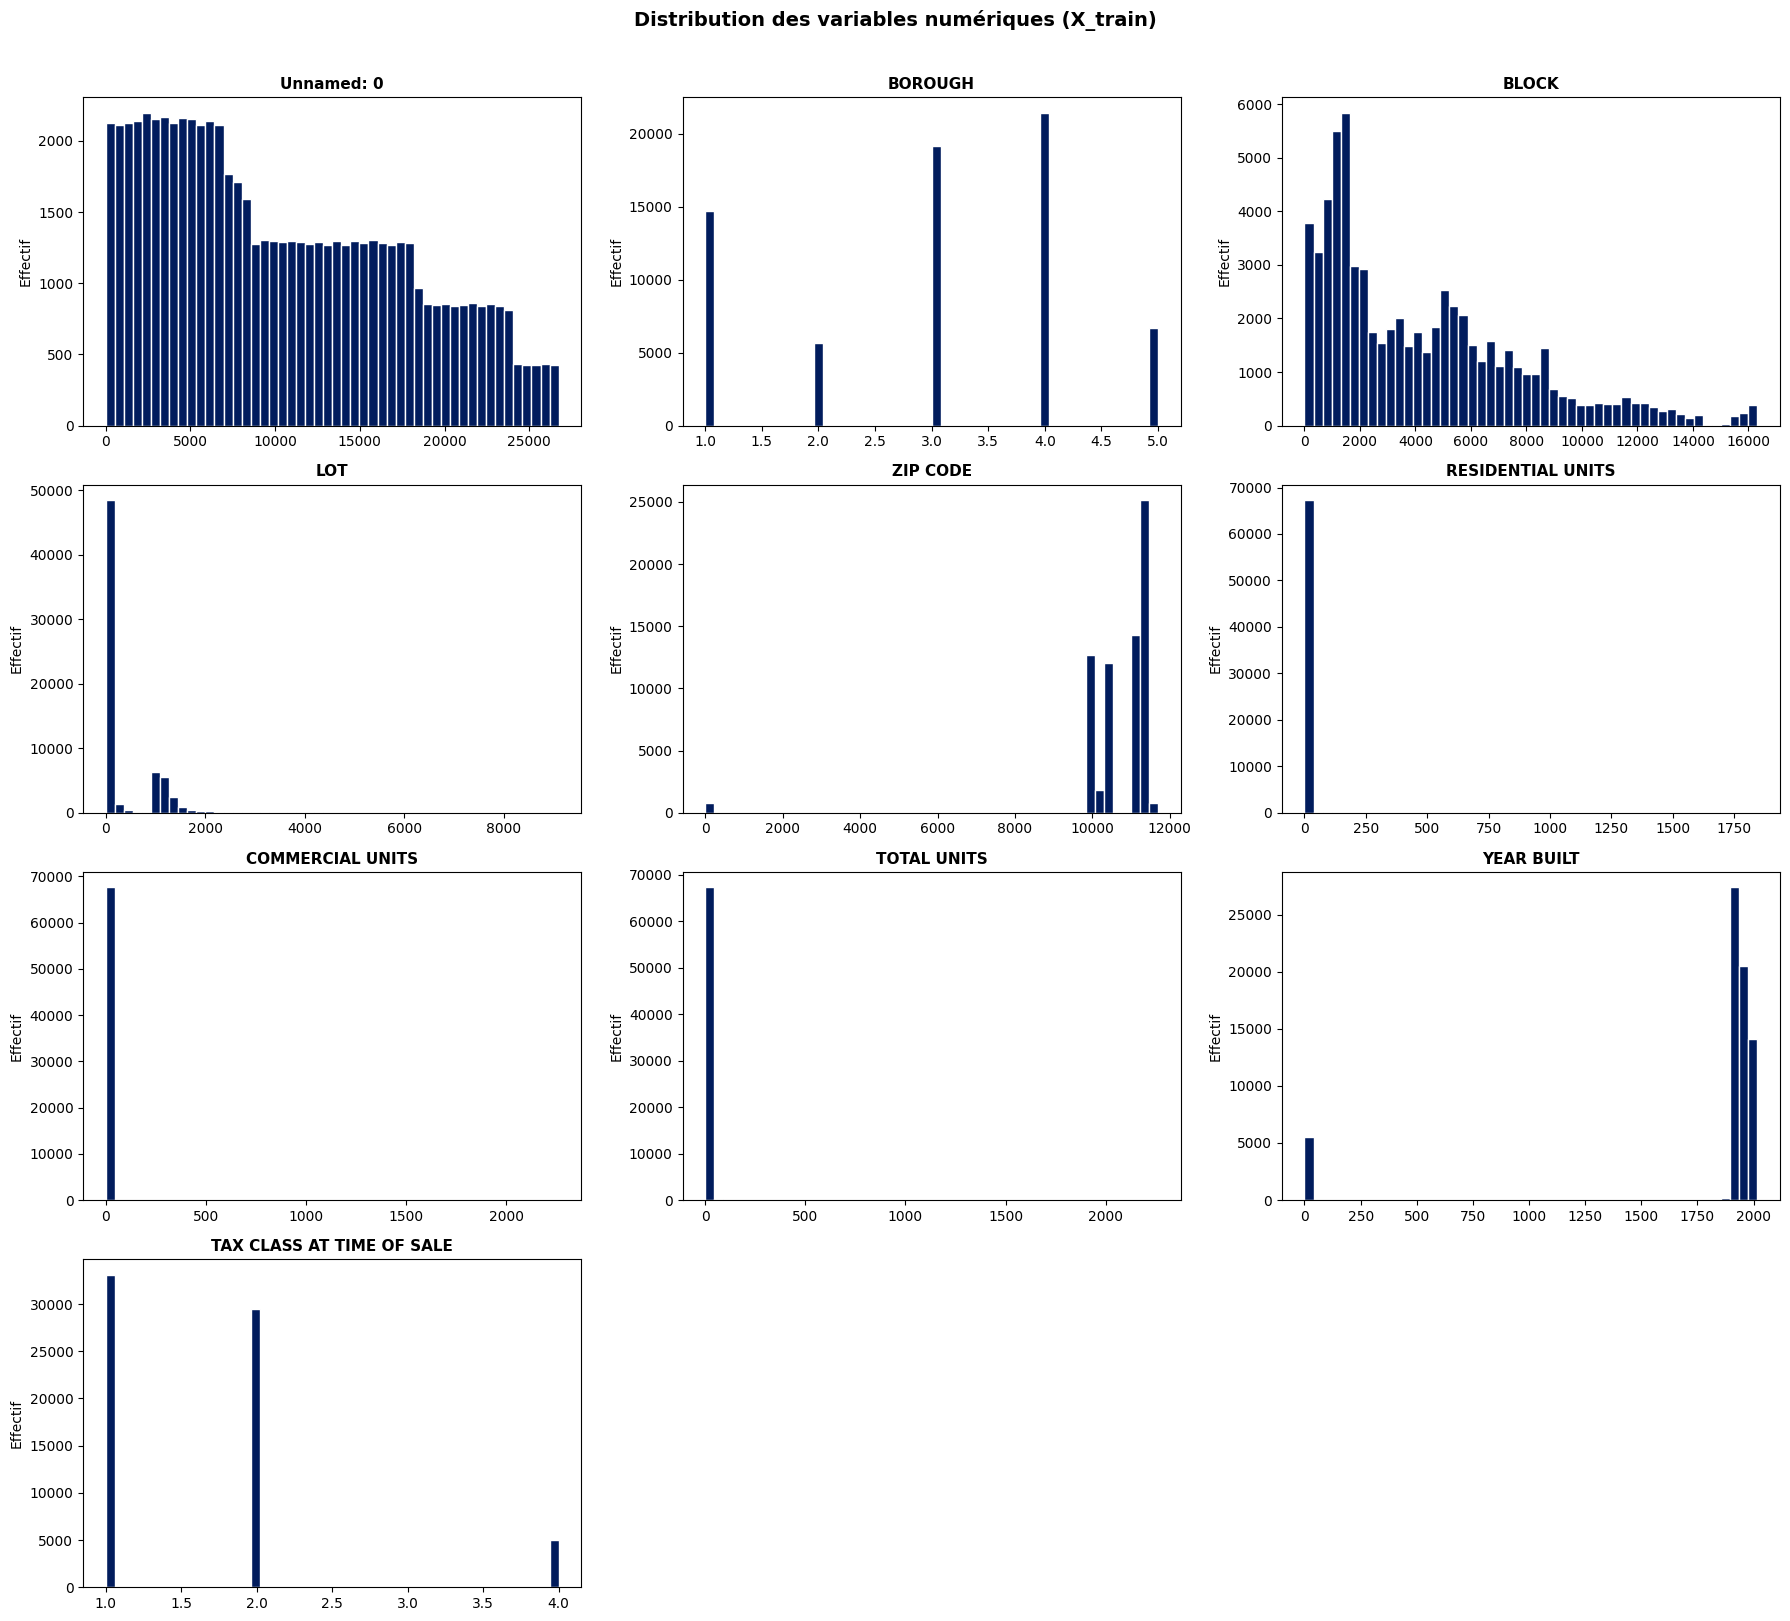

In [11]:
# Distributions des variables numériques (X_train) — Histogrammes
fig, axes = plt.subplots(
    nrows=(len(num_cols) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(num_cols) + 2) // 3))
)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(X_train[col].dropna(), bins=50, color="#011c5d", edgecolor="white")
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Effectif")

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables numériques (X_train)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# Aperçu des 5 premières lignes du jeu d'entraînement
print(" APERÇU DES 5 PREMIÈRES LIGNES (X_train)\n")
X_train.head()

 APERÇU DES 5 PREMIÈRES LIGNES (X_train)



,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE DATE
16283,16287,1,UPPER WEST SIDE (59-79),17 CONDO COOPS,2,1158,1007,,R9,"160 WEST END AVENUE, 28U",...,10023,0,0,0,-,-,1963,2,R9,2017-08-24 00:00:00
444,448,1,CHELSEA,10 COOPS - ELEVATOR APARTMENTS,2,790,1,,D4,"77 7TH AVENUE, 11S",...,10011,0,0,0,-,-,1963,2,D4,2017-07-20 00:00:00
34118,8767,3,CROWN HEIGHTS,02 TWO FAMILY DWELLINGS,1,1256,17,,B9,972A ST JOHNS PLACE,...,11213,2,0,2,2371,2348,1915,1,B9,2017-05-10 00:00:00
16636,16640,1,UPPER WEST SIDE (79-96),09 COOPS - WALKUP APARTMENTS,2C,1250,60,,C6,"344 WEST 89TH STREET, 3B",...,10024,0,0,0,-,-,1900,2,C6,2017-08-17 00:00:00
14286,14290,1,UPPER EAST SIDE (79-96),10 COOPS - ELEVATOR APARTMENTS,2,1579,49,,D4,"500 EAST 83RD STREET, 16ABC",...,10028,0,0,0,-,-,1965,2,D4,2017-05-05 00:00:00


In [13]:
# Vérification des doublons sur le jeu d'entraînement
print("\n" + "=" * 70)
print("  VÉRIFICATION DES DOUBLONS (X_train)")
print("=" * 70 + "\n")

# Doublons exacts
n_doublons_exacts = X_train.duplicated().sum()
pct_doublons_exacts = (n_doublons_exacts / len(X_train)) * 100
print(f" Doublons exacts (toutes colonnes)           : {n_doublons_exacts} ({pct_doublons_exacts:.2f}%)")

# Doublons sans tenir compte de Unnamed: 0 (supposé unique)
if "Unnamed: 0" in X_train.columns:
    n_doublons_no_id = X_train.duplicated(subset=X_train.columns.difference(["Unnamed: 0"])).sum()
    pct_doublons_no_id = (n_doublons_no_id / len(X_train)) * 100
    print(f" Doublons (hors Unnamed: 0)                  : {n_doublons_no_id} ({pct_doublons_no_id:.2f}%)")

print("\n" + "=" * 70)


  VÉRIFICATION DES DOUBLONS (X_train)

 Doublons exacts (toutes colonnes)           : 0 (0.00%)
 Doublons (hors Unnamed: 0)                  : 957 (1.41%)



In [14]:
# Analyse des valeurs manquantes sur X_train
print("\n" + "=" * 70)
print("  ANALYSE DES VALEURS MANQUANTES (X_train)")
print("=" * 70 + "\n")

missing_data = pd.DataFrame({
    "Colonne": X_train.columns,
    "Manquantes": X_train.isnull().sum().values,
    "Pourcentage": (X_train.isnull().sum().values / len(X_train) * 100).round(2)
})

missing_data_filtered = missing_data[missing_data["Manquantes"] > 0].sort_values("Manquantes", ascending=False)

if len(missing_data_filtered) > 0:
    print("  Colonnes avec valeurs manquantes :\n")
    display(missing_data_filtered.reset_index(drop=True))
else:
    print(" Aucune valeur manquante détectée dans X_train !")

print(f"\n Total de cellules manquantes     : {X_train.isnull().sum().sum()}")
print(f" Pourcentage global de complétude : {(1 - X_train.isnull().sum().sum() / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")
print("\n" + "=" * 70)


  ANALYSE DES VALEURS MANQUANTES (X_train)

 Aucune valeur manquante détectée dans X_train !

 Total de cellules manquantes     : 0
 Pourcentage global de complétude : 100.00%



In [15]:
# Types de données et complétude sur X_train
print("\n" + "=" * 70)
print("  INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES (X_train)")
print("=" * 70 + "\n")

info_df = pd.DataFrame({
    "Colonne": X_train.columns,
    "Type": X_train.dtypes.values,
    "Non-Null": X_train.notnull().sum().values,
    "Null": X_train.isnull().sum().values,
    "Null %": (X_train.isnull().sum().values / len(X_train) * 100).round(2)
})
display(info_df)

print("\n RÉSUMÉ DES TYPES :")
print(f"   • Variables numériques (int/float) : {X_train.select_dtypes(include=[np.number]).shape[1]}")
print(f"   • Variables catégorielles (object)  : {X_train.select_dtypes(include=['object']).shape[1]}")
print(f"   • Complétude globale              : {(1 - X_train.isnull().sum().sum() / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")


  INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES (X_train)



,Colonne,Type,Non-Null,Null,Null %
0,Unnamed: 0,int64,67638,0,0.0
1,BOROUGH,int64,67638,0,0.0
2,NEIGHBORHOOD,object,67638,0,0.0
3,BUILDING CLASS CATEGORY,object,67638,0,0.0
4,TAX CLASS AT PRESENT,object,67638,0,0.0
5,BLOCK,int64,67638,0,0.0
6,LOT,int64,67638,0,0.0
7,EASE-MENT,object,67638,0,0.0
8,BUILDING CLASS AT PRESENT,object,67638,0,0.0
9,ADDRESS,object,67638,0,0.0



 RÉSUMÉ DES TYPES :
   • Variables numériques (int/float) : 10
   • Variables catégorielles (object)  : 11
   • Complétude globale              : 100.00%


In [16]:
# Statistiques descriptives des variables numériques (X_train)
print("\n" + "=" * 70)
print("  STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES (X_train)")
print("=" * 70 + "\n")

X_train[num_cols].describe().round(2)


  STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES (X_train)



,Unnamed: 0,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,YEAR BUILT,TAX CLASS AT TIME OF SALE
count,67638.00,67638.00,67638.00,67638.00,67638.00,67638.00,67638.00,67638.00,67638.00,67638.00
mean,10328.90,3.00,4230.26,375.93,10730.89,2.05,0.21,2.29,1790.87,1.66
std,7141.30,1.29,3571.30,653.71,1291.96,17.44,9.68,20.08,534.93,0.82
min,4.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,4220.00,2.00,1319.00,22.00,10304.00,0.00,0.00,1.00,1920.00,1.00
50%,8936.00,3.00,3295.50,50.00,11209.00,1.00,0.00,1.00,1940.00,2.00
75%,15955.75,4.00,6269.75,1001.00,11357.00,2.00,0.00,2.00,1965.00,2.00
max,26739.00,5.00,16322.00,9106.00,11694.00,1844.00,2261.00,2261.00,2017.00,4.00


In [17]:
# Boxplots interactifs des variables numériques (X_train)
fig = make_subplots(
    rows=1, cols=len(num_cols),
    subplot_titles=num_cols
)

for i, col in enumerate(num_cols, 1):
    fig.add_trace(
        go.Box(y=X_train[col], name=col, marker_color="#011c5d"),
        row=1, col=i
    )

fig.update_layout(
    title_text="Boxplots des variables numériques (X_train)",
    height=500,
    width=300 * len(num_cols),
    showlegend=False
)

fig.show()

In [18]:
# Échantillon aléatoire pour validation de cohérence (X_train)
print(" APERÇU DE 10 LIGNES ALÉATOIRES (X_train)\n")
X_train.sample(10, random_state=42)

 APERÇU DE 10 LIGNES ALÉATOIRES (X_train)



,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE DATE
73096,23698,4,SOUTH OZONE PARK,01 ONE FAMILY DWELLINGS,1,11803,12,,A5,135-49 116TH STREET,...,11420,1,0,1,2000,1600,1950,1,A5,2017-06-07 00:00:00
75519,26121,4,WOODHAVEN,02 TWO FAMILY DWELLINGS,1,8904,58,,B3,87-09 75TH STREET,...,11421,2,0,2,1947,1171,1910,1,B3,2017-01-05 00:00:00
21494,3192,2,MORRISANIA/LONGWOOD,05 TAX CLASS 1 VACANT LAND,1B,2674,9,,V0,569-575 PROSPECT AVENUE,...,10455,0,2,2,10000,0,1920,1,V0,2017-06-27 00:00:00
28892,3541,3,BOERUM HILL,15 CONDOS - 2-10 UNIT RESIDENTIAL,2C,396,1102,,R1,304 WARREN STREET,...,11201,1,0,1,0,0,1900,2,R1,2016-12-16 00:00:00
61694,12296,4,GLENDALE,01 ONE FAMILY DWELLINGS,1,3820,50,,A5,77-12 82ND STREET,...,11385,1,0,1,1800,1224,1940,1,A5,2017-04-12 00:00:00
32575,7224,3,CANARSIE,02 TWO FAMILY DWELLINGS,1,8220,48,,B2,1264 E. 94TH STREET,...,11236,2,0,2,2200,1872,1930,1,B2,2017-06-08 00:00:00
77137,1003,5,CASTLETON CORNERS,01 ONE FAMILY DWELLINGS,1,369,123,,A2,121 KEMBALL AVENUE,...,10314,1,0,1,4040,1075,1955,1,A2,2016-10-21 00:00:00
45589,20238,3,PROSPECT HEIGHTS,13 CONDOS - ELEVATOR APARTMENTS,2,1129,1174,,R4,550 VANDERBILT AVENUE,...,11238,1,0,1,0,0,2015,2,R4,2017-06-19 00:00:00
3576,3580,1,GREENWICH VILLAGE-CENTRAL,09 COOPS - WALKUP APARTMENTS,2C,575,31,,C6,"48 WEST 12TH STREET, 3R",...,10011,0,0,0,-,-,1931,2,C6,2017-06-14 00:00:00
21587,3285,2,MORRISANIA/LONGWOOD,14 RENTALS - 4-10 UNIT,2B,2999,24,,S9,1452 BRYANT AVENUE,...,10459,5,3,8,2500,3300,1931,2,S9,2016-09-13 00:00:00


In [19]:
# Analyse détaillée des valeurs manquantes et recommandations
print("\n" + "=" * 70)
print("  STRATÉGIE DE TRAITEMENT DES VALEURS MANQUANTES (X_train)")
print("=" * 70 + "\n")

missing_analysis = pd.DataFrame({
    "Colonne": X_train.columns,
    "Manquants": X_train.isnull().sum().values,
    "Manquants %": (X_train.isnull().sum().values / len(X_train) * 100).round(2),
    "Status": [" OK" if x == 0 else "  À traiter" for x in X_train.isnull().sum().values]
})

missing_analysis = missing_analysis[missing_analysis["Manquants"] > 0].sort_values("Manquants", ascending=False)

if len(missing_analysis) == 0:
    print(" EXCELLENT : Aucune valeur manquante détectée dans X_train !")
    print("   Le dataset est complet et prêt pour la modélisation.")
else:
    print("  VALEURS MANQUANTES DÉTECTÉES :\n")
    display(missing_analysis)
    print("\n RECOMMANDATIONS :")
    for _, row in missing_analysis.iterrows():
        pct = row["Manquants %"]
        if pct < 1:
            print(f"   • {row['Colonne']} ({pct}%) : Supprimer les lignes")
        elif pct < 5:
            print(f"   • {row['Colonne']} ({pct}%) : Imputer (moyenne/médiane/mode)")
        elif pct < 30:
            print(f"   • {row['Colonne']} ({pct}%) : Analyser le pattern d'absence")
        else:
            print(f"   • {row['Colonne']} ({pct}%) :  Considérer la suppression")


  STRATÉGIE DE TRAITEMENT DES VALEURS MANQUANTES (X_train)

 EXCELLENT : Aucune valeur manquante détectée dans X_train !
   Le dataset est complet et prêt pour la modélisation.


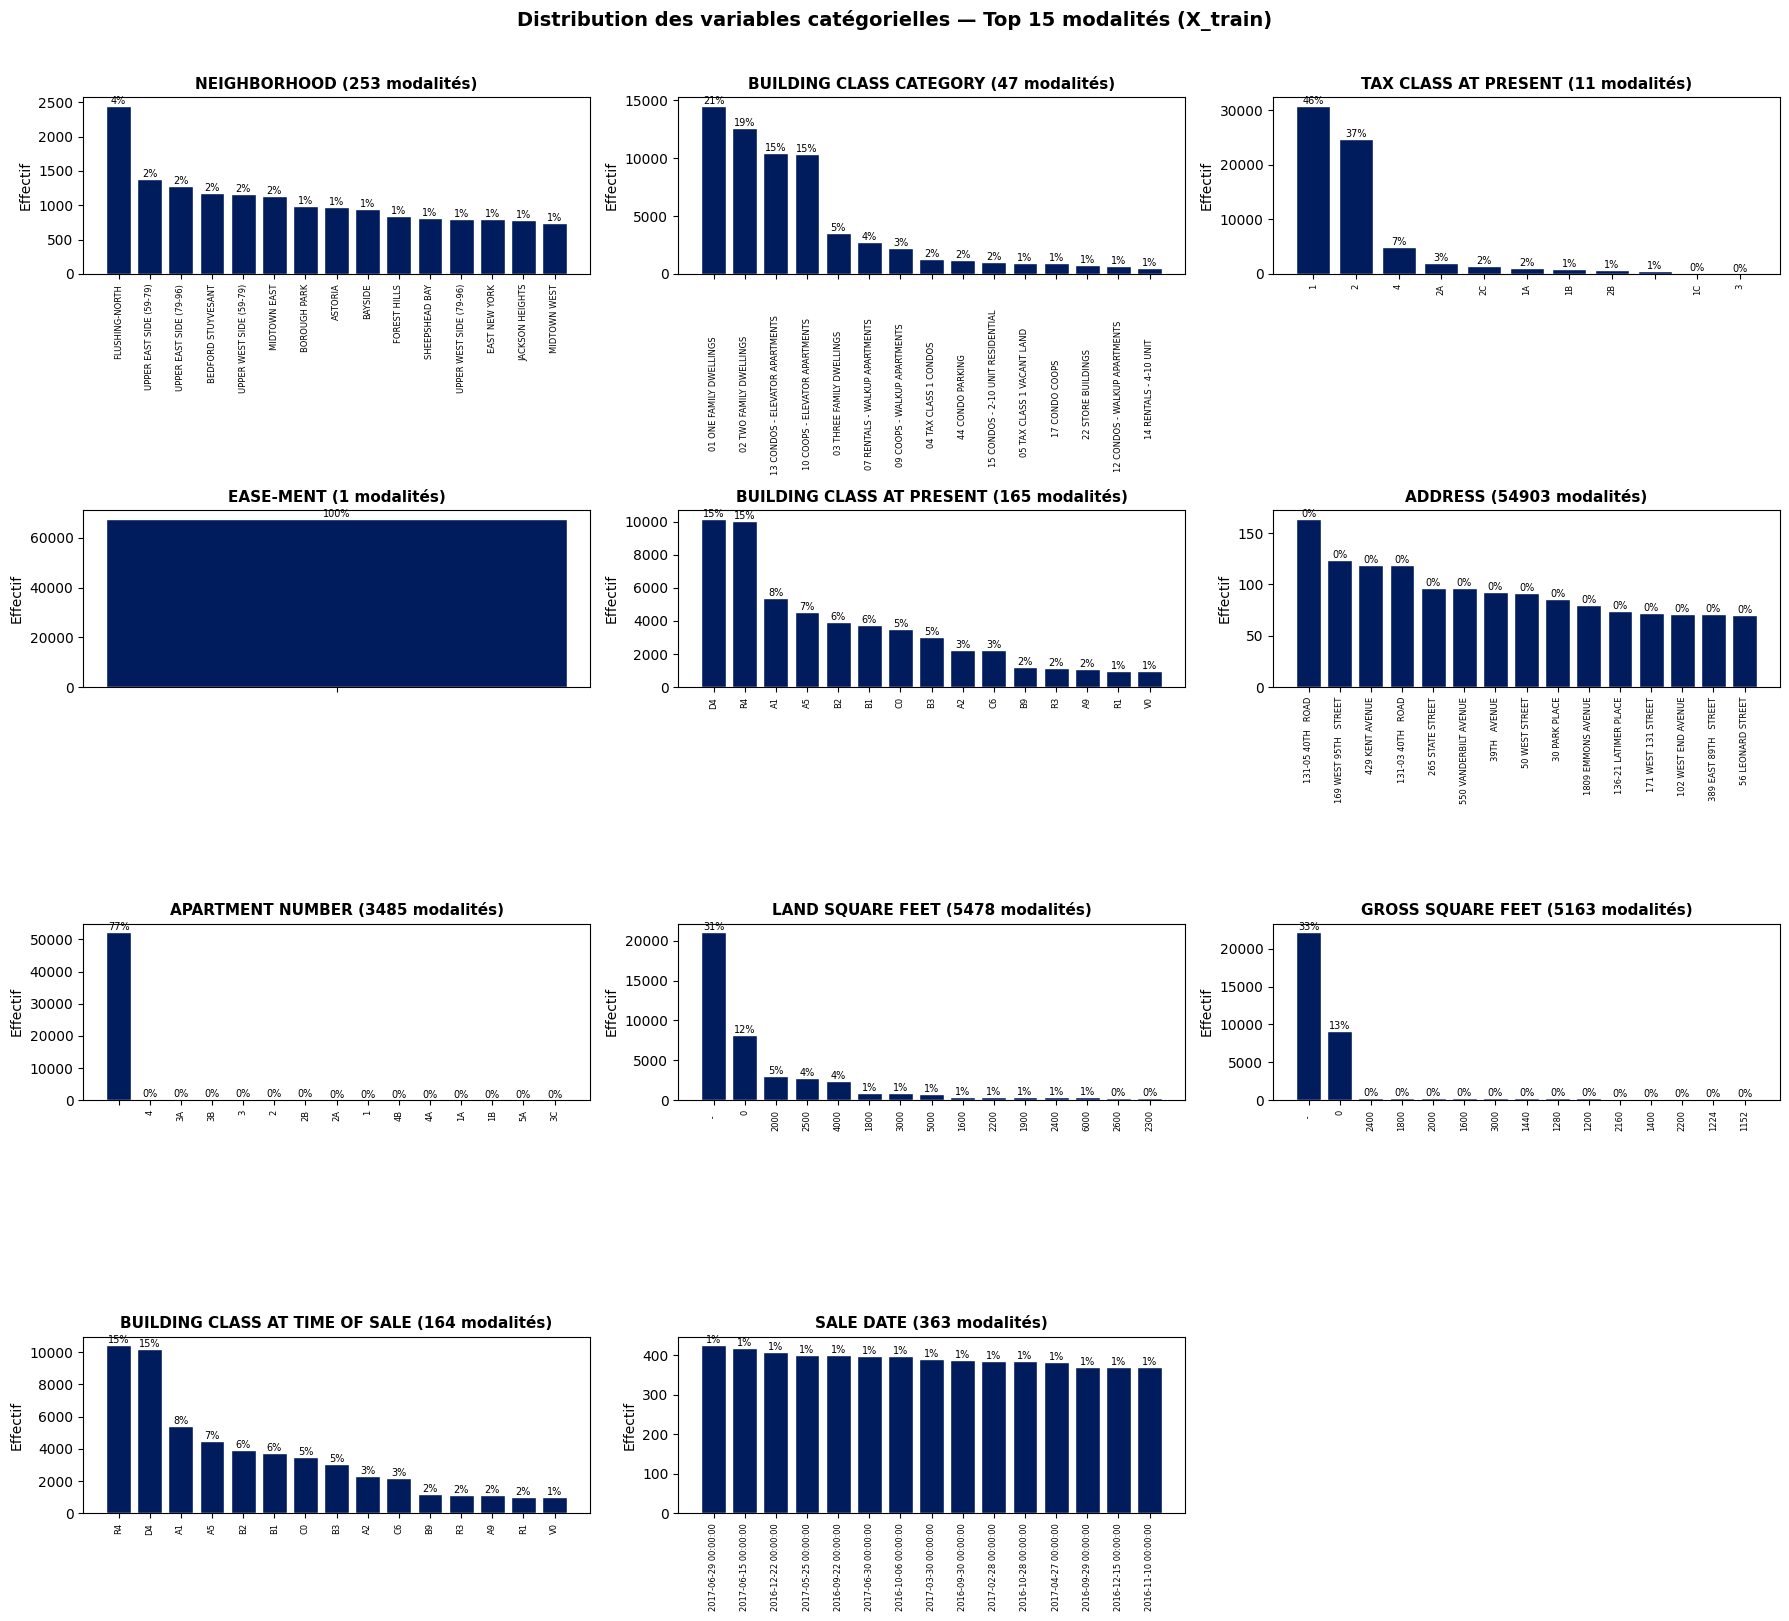

In [41]:
# Distribution des variables catégorielles (X_train)
cat_cols_analysis = cat_cols.copy()

n_cols_plot = 3
n_rows_plot = (len(cat_cols_analysis) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols_analysis):
    counts = X_train[col].value_counts().head(15)  # Top 15 modalités
    bars = axes[i].bar(range(len(counts)), counts.values, color="#011c5d", edgecolor="white")
    axes[i].set_title(f"{col} ({X_train[col].nunique()} modalités)", fontsize=11, fontweight="bold")
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=90, ha="center", fontsize=6)  # <- modifié ici
    axes[i].set_ylabel("Effectif")

    # Annotation des pourcentages
    total = X_train[col].value_counts().sum()
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f"{val / total:.0%}", ha="center", va="bottom", fontsize=7)

# Masquer les axes inutilisés
for j in range(len(cat_cols_analysis), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables catégorielles — Top 15 modalités (X_train)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Détection des outliers avec la fonction importée de utils/data_prep.py
print("\n" + "=" * 70)
print("  DÉTECTION DES OUTLIERS — MÉTHODE IQR (X_train)")
print("=" * 70 + "\n")

outlier_summary = []

for col in num_cols:
    outlier_idx, lower, upper = detect_possible_outliers(X_train, col)
    n_outliers = len(outlier_idx)
    pct = (n_outliers / len(X_train)) * 100
    outlier_summary.append({
        "Variable": col,
        "Nb Outliers": n_outliers,
        "% du train": round(pct, 2),
        "Borne basse": round(lower, 2),
        "Borne haute": round(upper, 2),
        "Min réel": round(X_train[col].min(), 2),
        "Max réel": round(X_train[col].max(), 2)
    })
    status = "" if n_outliers > 0 else ""
    print(f"  {status} {col:<25s} : {n_outliers:>5d} outliers ({pct:.1f}%)  |  bornes [{lower:.1f} ; {upper:.1f}]")

outlier_df = pd.DataFrame(outlier_summary)

print("\n Note : Certains outliers peuvent refléter des biens de luxe ou")
print("   des transactions atypiques — à analyser avant suppression.")


  DÉTECTION DES OUTLIERS — MÉTHODE IQR (X_train)

   Unnamed: 0                :     0 outliers (0.0%)  |  bornes [-13383.6 ; 33559.4]
   BOROUGH                   :     0 outliers (0.0%)  |  bornes [-1.0 ; 7.0]
   BLOCK                     :  1167 outliers (1.7%)  |  bornes [-6107.1 ; 13695.9]
   LOT                       :   673 outliers (1.0%)  |  bornes [-1446.5 ; 2469.5]
   ZIP CODE                  :   787 outliers (1.2%)  |  bornes [8724.5 ; 12936.5]
   RESIDENTIAL UNITS         :  2207 outliers (3.3%)  |  bornes [-3.0 ; 5.0]
   COMMERCIAL UNITS          :  4095 outliers (6.1%)  |  bornes [0.0 ; 0.0]
   TOTAL UNITS               :  4092 outliers (6.0%)  |  bornes [-0.5 ; 3.5]
   YEAR BUILT                :  5580 outliers (8.2%)  |  bornes [1852.5 ; 2032.5]
   TAX CLASS AT TIME OF SALE :  5051 outliers (7.5%)  |  bornes [-0.5 ; 3.5]

 Note : Certains outliers peuvent refléter des biens de luxe ou
   des transactions atypiques — à analyser avant suppression.


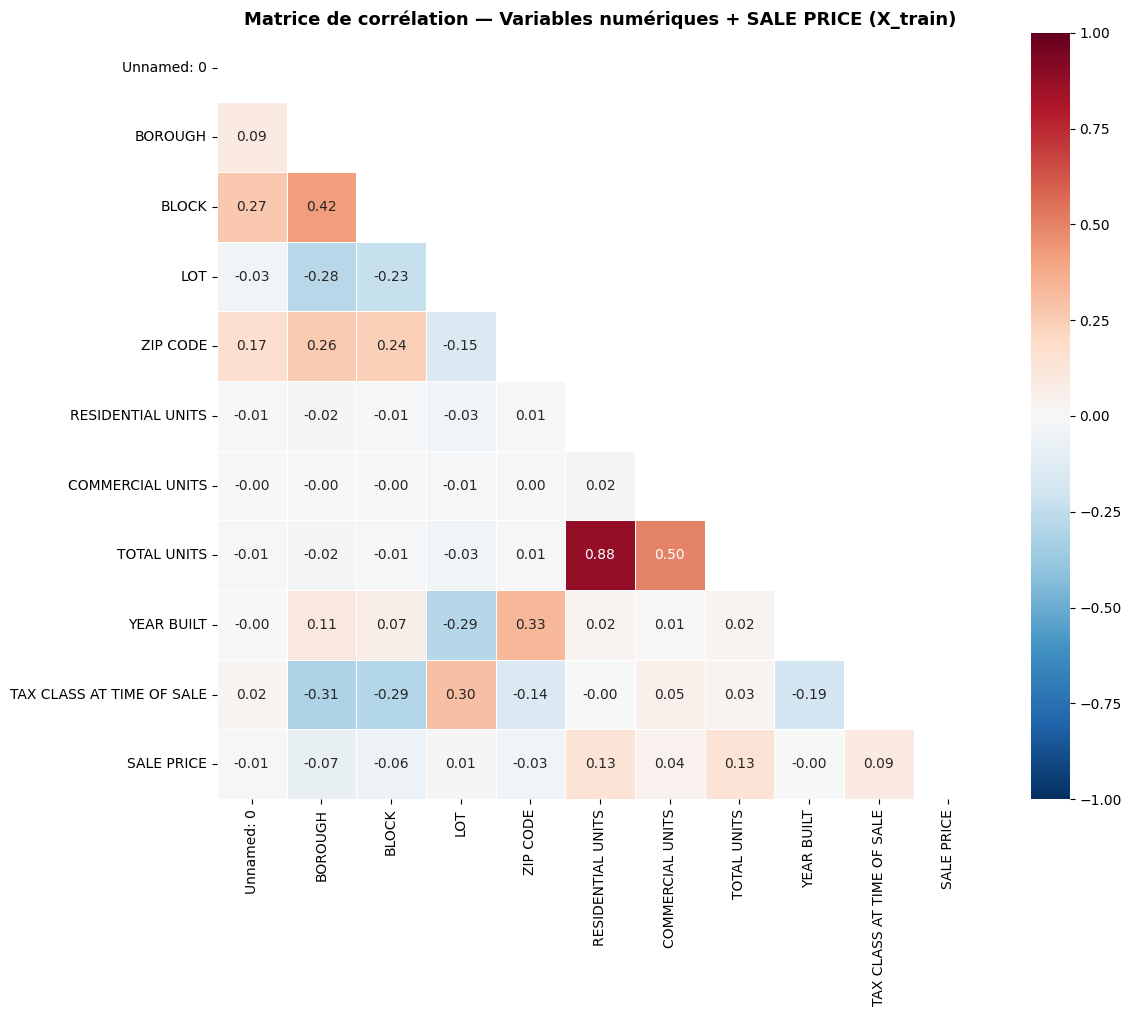


 Corrélations avec SALE PRICE :
   TOTAL UNITS               : +0.135  (faible)
   RESIDENTIAL UNITS         : +0.134  (faible)
   TAX CLASS AT TIME OF SALE : +0.087  (faible)
   BOROUGH                   : -0.073  (faible)
   BLOCK                     : -0.060  (faible)
   COMMERCIAL UNITS          : +0.044  (faible)
   ZIP CODE                  : -0.032  (faible)
   Unnamed: 0                : -0.014  (faible)
   LOT                       : +0.013  (faible)
   YEAR BUILT                : -0.003  (faible)


In [22]:
# Matrice de corrélation — variables numériques + cible (SALE PRICE)
train_corr = X_train[num_cols].copy()
train_corr[Target] = y_train.values

corr_matrix = train_corr.corr()

# Heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title("Matrice de corrélation — Variables numériques + SALE PRICE (X_train)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Corrélations avec la cible
print("\n Corrélations avec SALE PRICE :")
price_corr = corr_matrix[Target].drop(Target).sort_values(key=abs, ascending=False)
for var, val in price_corr.items():
    signe = "+" if val > 0 else ""
    force = "forte" if abs(val) > 0.3 else "modérée" if abs(val) > 0.15 else "faible"
    print(f"   {var:<25s} : {signe}{val:.3f}  ({force})")

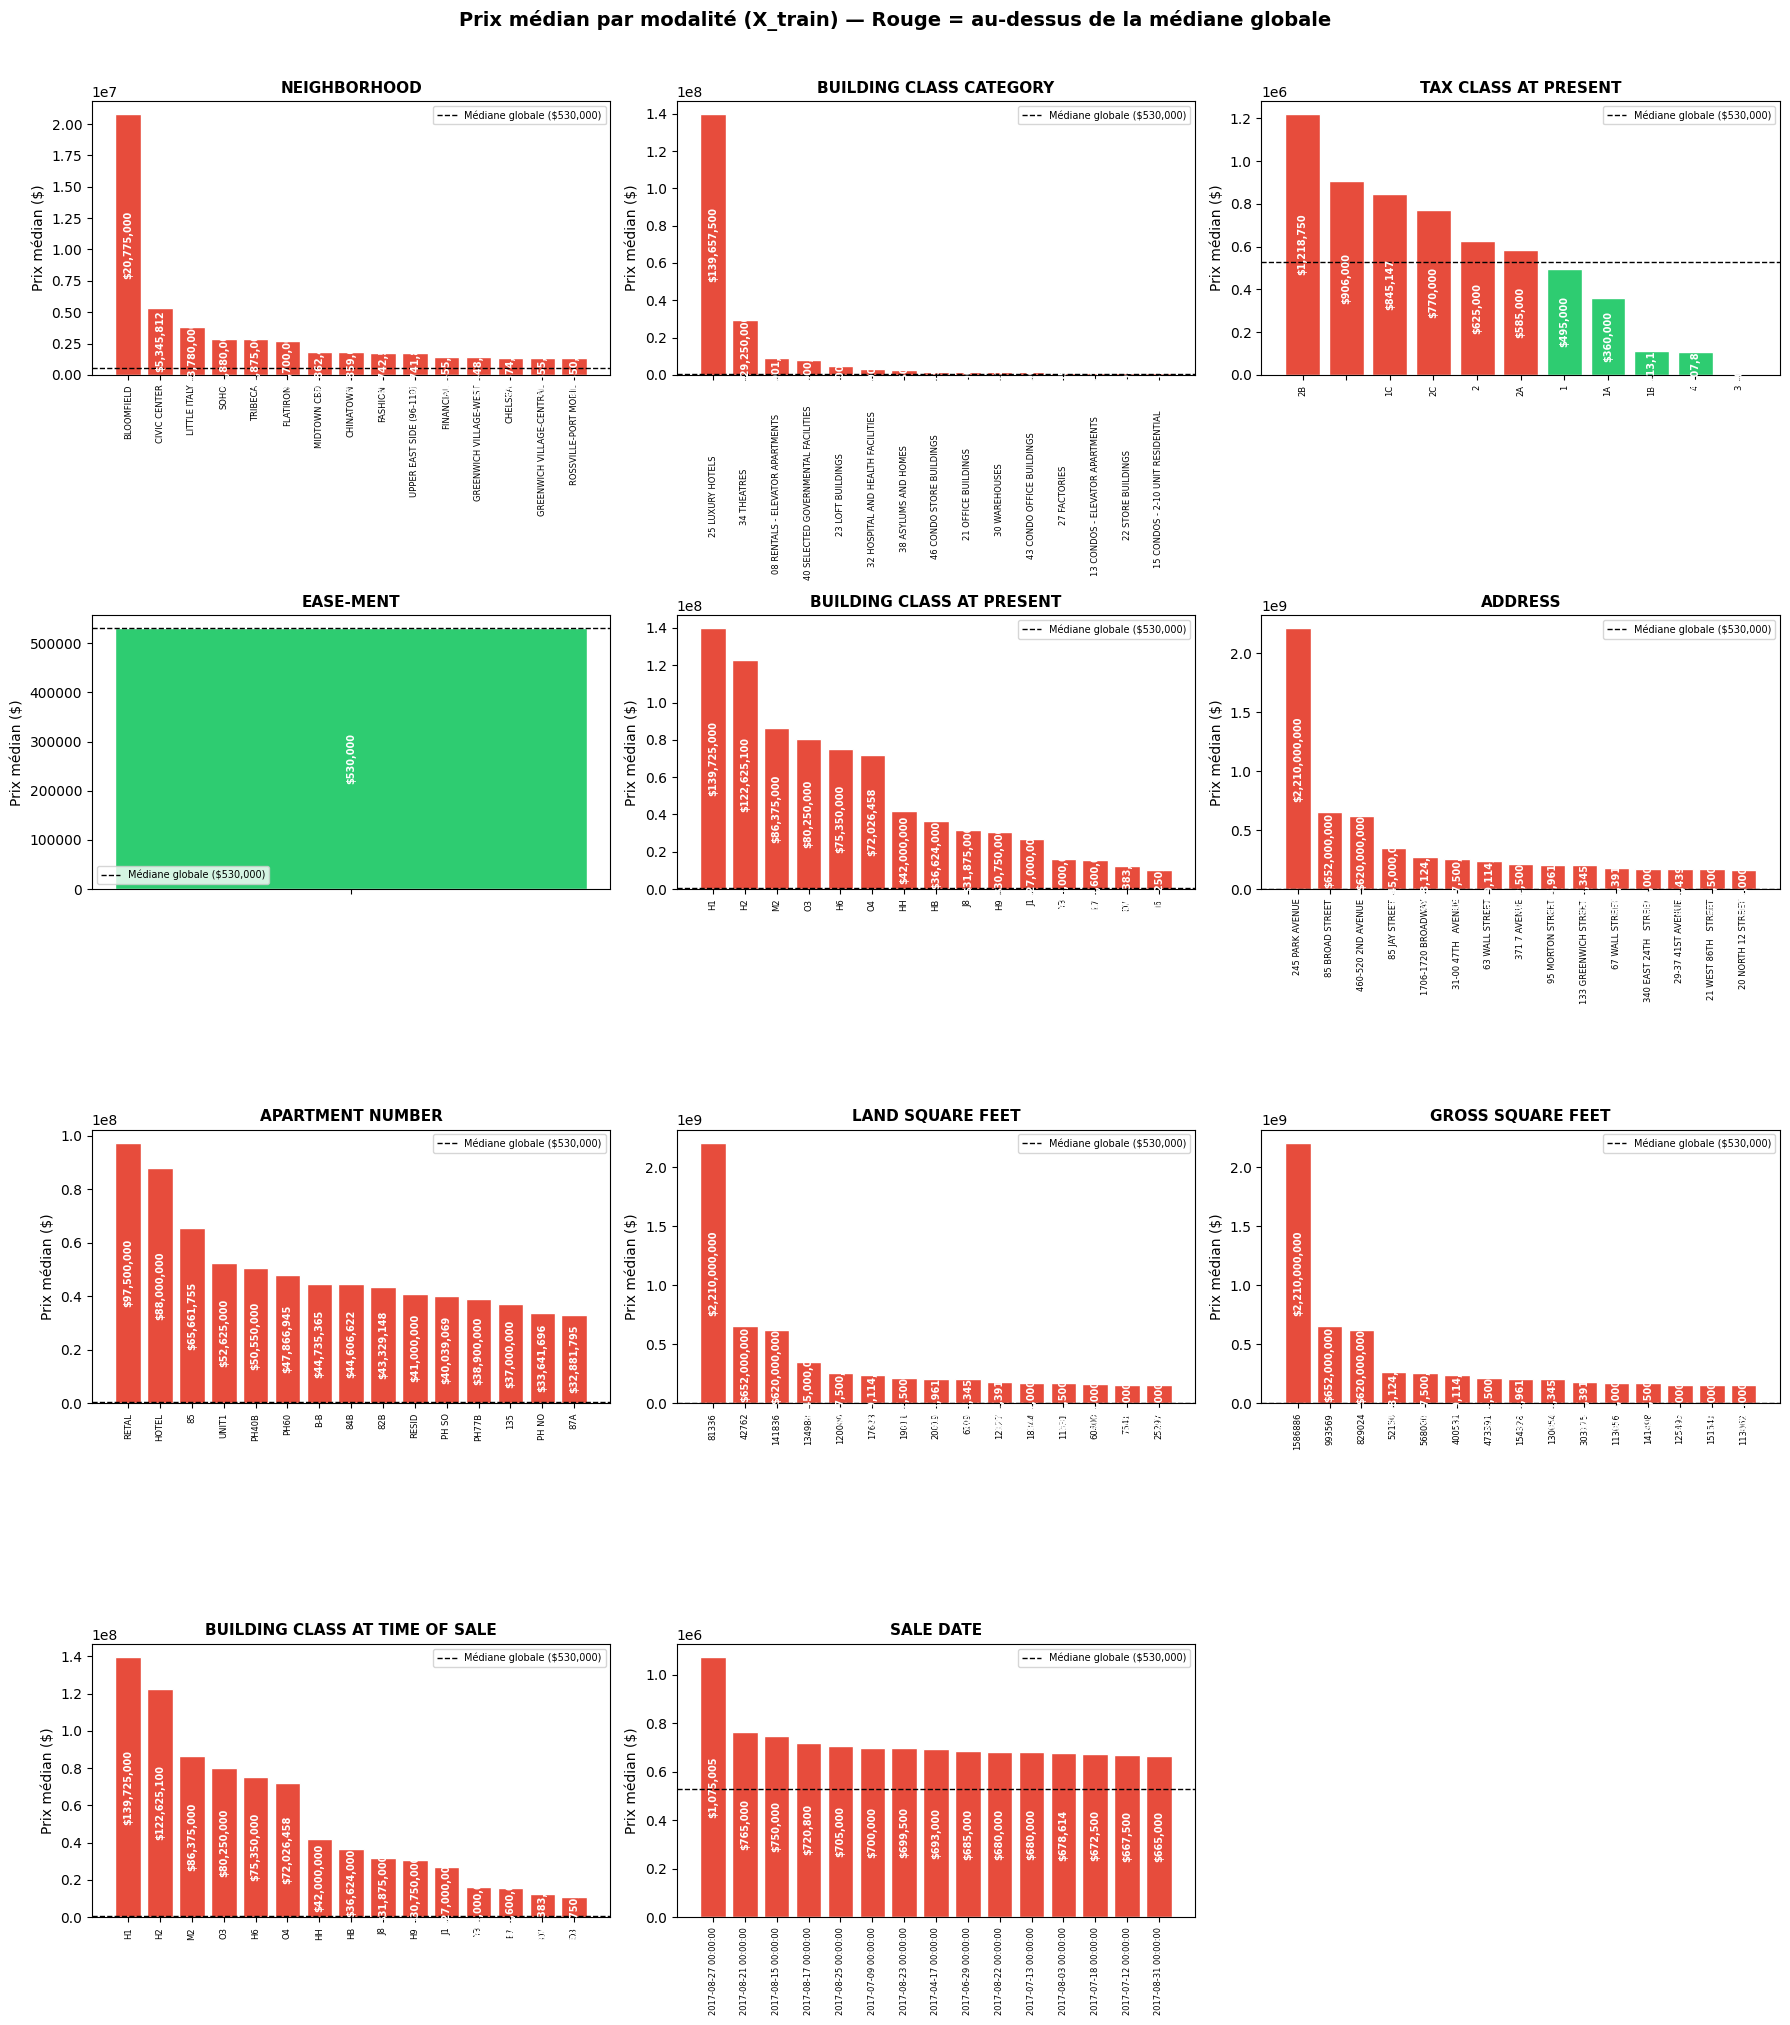

In [42]:
# Prix médian par variable catégorielle (X_train)
cat_cols_analysis = cat_cols.copy()

# Préparer les données : concaténer X_train avec y_train
train_analysis = X_train.copy()
train_analysis[Target] = y_train.values
prix_median_global = train_analysis[Target].median()

n_cols_plot = 3
n_rows_plot = (len(cat_cols_analysis) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols_analysis):
    # Calcul du prix médian par modalité (top 15)
    median_prices = train_analysis.groupby(col)[Target].median().sort_values(ascending=False).head(15)

    bars = axes[i].bar(
        range(len(median_prices)),
        median_prices.values,
        color=["#e74c3c" if v > prix_median_global else "#2ecc71" for v in median_prices.values],
        edgecolor="white"
    )

    axes[i].axhline(
        y=prix_median_global,
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"Médiane globale (${prix_median_global:,.0f})"
    )

    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_xticks(range(len(median_prices)))
    axes[i].set_xticklabels(
        median_prices.index,
        rotation=90,   # <- vertical
        ha="center",   # <- centré sous la barre
        fontsize=6     # <- police plus petite
    )
    axes[i].set_ylabel("Prix médian ($)")
    axes[i].legend(fontsize=7)

    # Texte vertical sur les barres
    for bar, val in zip(bars, median_prices.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.5,
            f"${val:,.0f}",
            ha="center",
            va="center",
            rotation=90,
            fontsize=7,
            fontweight="bold",
            color="white"
        )

# Masquer les axes inutilisés
for j in range(len(cat_cols_analysis), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Prix médian par modalité (X_train) — Rouge = au-dessus de la médiane globale",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

In [24]:
# Test Kruskal-Wallis pour chaque variable catégorielle vs SALE PRICE
print("\n" + "=" * 70)
print("  TEST DE KRUSKAL-WALLIS — ASSOCIATION AVEC SALE PRICE (X_train)")
print("=" * 70 + "\n")

alpha = 0.05
kruskal_results = []

train_analysis = X_train.copy()
train_analysis[Target] = y_train.values

for col in cat_cols_analysis:
    # Grouper les prix par modalité (exclure NaN)
    groups = [group[Target].dropna().values for _, group in train_analysis.groupby(col) if len(group[Target].dropna()) > 1]

    if len(groups) >= 2:
        stat, p_value = ss.kruskal(*groups)
        significant = " Significatif" if p_value < alpha else " Non significatif"
        kruskal_results.append({
            "Variable": col,
            "Statistique H": round(stat, 2),
            "p-value": f"{p_value:.2e}" if p_value < 0.001 else f"{p_value:.4f}",
            "Nb modalités": train_analysis[col].nunique(),
            "Résultat": significant
        })

kruskal_df = pd.DataFrame(kruskal_results).sort_values("Statistique H", ascending=False)
display(kruskal_df.reset_index(drop=True))

n_signif = sum(1 for r in kruskal_results if "Significatif" in r["Résultat"] and "Non" not in r["Résultat"])
print(f"\n {n_signif}/{len(kruskal_results)} variables catégorielles ont un effet significatif sur SALE PRICE (α = {alpha})")
print("   Test non paramétrique : pas d'hypothèse de normalité requise.")


  TEST DE KRUSKAL-WALLIS — ASSOCIATION AVEC SALE PRICE (X_train)



,Variable,Statistique H,p-value,Nb modalités,Résultat
0,NEIGHBORHOOD,15973.14,0.00e+00,253,Significatif
1,ADDRESS,9507.91,0.00e+00,54903,Significatif
2,BUILDING CLASS AT TIME OF SALE,9207.00,0.00e+00,164,Significatif
3,BUILDING CLASS AT PRESENT,8928.68,0.00e+00,165,Significatif
4,BUILDING CLASS CATEGORY,8055.72,0.00e+00,47,Significatif
5,GROSS SQUARE FEET,7311.11,0.00e+00,5163,Significatif
6,LAND SQUARE FEET,6902.18,0.00e+00,5478,Significatif
7,APARTMENT NUMBER,5799.64,0.00e+00,3485,Significatif
8,TAX CLASS AT PRESENT,2586.06,0.00e+00,11,Significatif
9,SALE DATE,1660.60,3.99e-171,363,Significatif



 10/10 variables catégorielles ont un effet significatif sur SALE PRICE (α = 0.05)
   Test non paramétrique : pas d'hypothèse de normalité requise.


In [25]:
# ============================================================
# ÉTAPE 2 : Analyse de la Variable Cible (SALE PRICE)
# ============================================================
print("\n" + "=" * 70)
print("  ANALYSE DE LA VARIABLE CIBLE : SALE PRICE (y_train)")
print("=" * 70 + "\n")

y_clean = y_train.dropna()
y_positive = y_clean[y_clean > 0]

print(f"  Nombre total de transactions     : {len(y_train):,}")
print(f"  Valeurs manquantes (NaN)         : {y_train.isna().sum():,} ({y_train.isna().mean()*100:.2f}%)")
print(f"  Transactions à $0                : {(y_clean == 0).sum():,}")
print(f"  Transactions valides (> $0)      : {len(y_positive):,}")

print(f"\n  --- Statistiques sur prix > $0 ---")
print(f"  Prix moyen                       : ${y_positive.mean():,.2f}")
print(f"  Prix médian                      : ${y_positive.median():,.2f}")
print(f"  Écart-type                       : ${y_positive.std():,.2f}")
print(f"  Min                              : ${y_positive.min():,.2f}")
print(f"  Max                              : ${y_positive.max():,.2f}")

# Diagnostic de normalité
skewness = y_positive.skew()
kurtosis = y_positive.kurtosis()
print(f"\n  Skewness (asymétrie)             : {skewness:.2f}")
print(f"  Kurtosis (aplatissement)         : {kurtosis:.2f}")

if abs(skewness) > 2:
    print("    Distribution TRÈS asymétrique → transformation log recommandée")
elif abs(skewness) > 1:
    print("    Distribution asymétrique → envisager une transformation")
else:
    print("    Distribution raisonnablement symétrique")

# Rapport moyenne/médiane
ratio = y_positive.mean() / y_positive.median()
print(f"\n  Ratio Moyenne/Médiane            : {ratio:.2f}")
if ratio > 1.5:
    print("    Forte présence de valeurs élevées tirant la moyenne vers le haut")
    print("    → La médiane est un meilleur indicateur de tendance centrale")

print("\n" + "=" * 70)


  ANALYSE DE LA VARIABLE CIBLE : SALE PRICE (y_train)

  Nombre total de transactions     : 67,638
  Valeurs manquantes (NaN)         : 11,745 (17.36%)
  Transactions à $0                : 8,141
  Transactions valides (> $0)      : 47,752

  --- Statistiques sur prix > $0 ---
  Prix moyen                       : $1,490,681.19
  Prix médian                      : $625,000.00
  Écart-type                       : $12,336,300.38
  Min                              : $1.00
  Max                              : $2,210,000,000.00

  Skewness (asymétrie)             : 128.38
  Kurtosis (aplatissement)         : 21847.52
    Distribution TRÈS asymétrique → transformation log recommandée

  Ratio Moyenne/Médiane            : 2.39
    Forte présence de valeurs élevées tirant la moyenne vers le haut
    → La médiane est un meilleur indicateur de tendance centrale



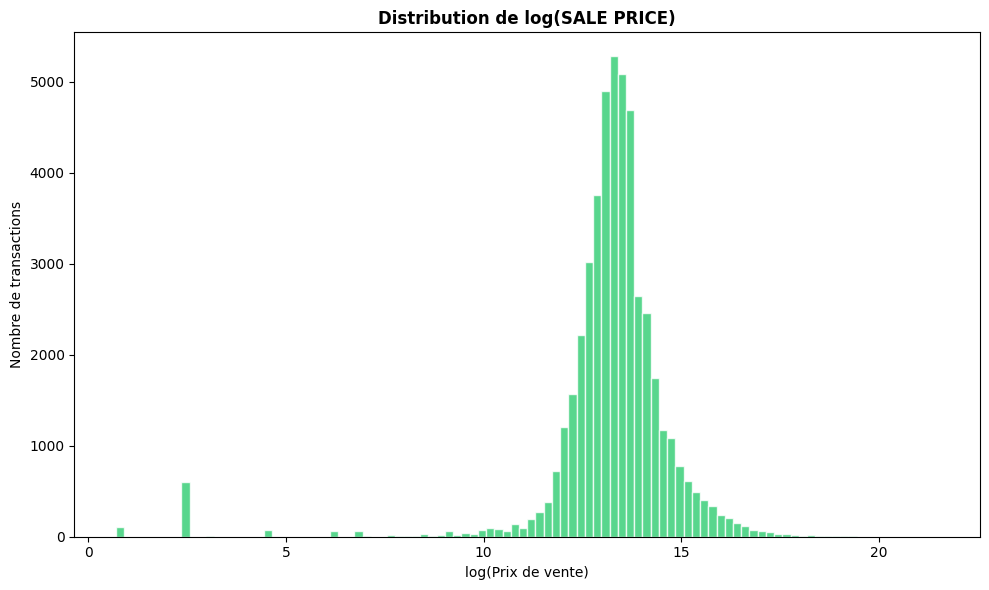

In [40]:
# Visualisation de la distribution log de SALE PRICE (y_train)
y_positive = y_train[y_train > 0].dropna()

plt.figure(figsize=(10,6))

plt.hist(np.log1p(y_positive), bins=100, color="#2ecc71", edgecolor="white", alpha=0.8)

plt.title("Distribution de log(SALE PRICE)", fontsize=12, fontweight="bold")
plt.xlabel("log(Prix de vente)")
plt.ylabel("Nombre de transactions")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# SYNTHÈSE DE L'EXPLORATION
# ============================================================
print("\n" + "=" * 70)
print("  SYNTHÈSE & IMPLICATIONS POUR LA MODÉLISATION")
print("=" * 70 + "\n")

y_positive = y_train[y_train > 0].dropna()
skewness = y_positive.skew()

print(" STRATÉGIES À ENVISAGER :\n")

# 1. Transformation de la cible
print("1  TRANSFORMATION DE LA CIBLE")
if abs(skewness) > 2:
    print("   La distribution de SALE PRICE est TRÈS asymétrique.")
    print("    Option A : Transformation log(y) pour normaliser")
    print("    Option B : Transformation Box-Cox")
    print("    Ne pas oublier l'inverse (exp) pour les prédictions finales")
else:
    print("   La distribution est raisonnablement symétrique.")
    print("    Pas de transformation nécessaire a priori")

# 2. Métriques d'évaluation
print("\n2  MÉTRIQUES D'ÉVALUATION (RÉGRESSION)")
print("    RMSE : pénalise les grosses erreurs")
print("    MAE  : robuste aux outliers")
print("    R²   : variance expliquée par le modèle")
print("    MAPE : erreur en pourcentage (interprétable métier)")

# 3. Gestion des outliers
print("\n3  GESTION DES OUTLIERS")
print("   Les biens de luxe créent des outliers naturels.")
print("    Option A : Cap les prix extrêmes (winsorization)")
print("    Option B : Modéliser sur log(prix) pour réduire l'impact")
print("    Option C : Segmenter luxe vs standard")

# 4. Score de valorisation (objectif métier)
print("\n4  SCORE DE VALORISATION (OBJECTIF MÉTIER)")
print("   Le modèle prédit un prix théorique → comparer au prix réel.")
print("    Score = (Prix réel - Prix prédit) / Prix prédit × 100")
print("    • Score > 0 : bien en SURCOTE (vendu au-dessus de l'estimation)")
print("    • Score < 0 : bien en DÉCOTE (opportunité d'investissement)")

# 5. Prochaines étapes
print("\n5  PROCHAINES ÉTAPES (Notebook 02)")
if len(y_train) < 5000:
    print("     Dataset petit : envisager un split 70-30 pour maximiser le train")
else:
    print("    Dataset suffisamment grand pour un split 80-20")
print("    Feature engineering (encodage, interactions, création de variables)")
print("    Modèle baseline (régression linéaire, Random Forest)")
print("    Optimisation des hyperparamètres")

print("\n" + "=" * 70)


  SYNTHÈSE & IMPLICATIONS POUR LA MODÉLISATION

 STRATÉGIES À ENVISAGER :

1  TRANSFORMATION DE LA CIBLE
   La distribution de SALE PRICE est TRÈS asymétrique.
    Option A : Transformation log(y) pour normaliser
    Option B : Transformation Box-Cox
    Ne pas oublier l'inverse (exp) pour les prédictions finales

2  MÉTRIQUES D'ÉVALUATION (RÉGRESSION)
    RMSE : pénalise les grosses erreurs
    MAE  : robuste aux outliers
    R²   : variance expliquée par le modèle
    MAPE : erreur en pourcentage (interprétable métier)

3  GESTION DES OUTLIERS
   Les biens de luxe créent des outliers naturels.
    Option A : Cap les prix extrêmes (winsorization)
    Option B : Modéliser sur log(prix) pour réduire l'impact
    Option C : Segmenter luxe vs standard

4  SCORE DE VALORISATION (OBJECTIF MÉTIER)
   Le modèle prédit un prix théorique → comparer au prix réel.
    Score = (Prix réel - Prix prédit) / Prix prédit × 100
    • Score > 0 : bien en SURCOTE (vendu au-dessus de l'estimation)
    • S